In [36]:
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Input
from sklearn.metrics import classification_report, confusion_matrix
from keras.layers import BatchNormalization
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score)

In [43]:
# Load preprocessed data
X_train = joblib.load("../models/X_train_processed.pkl")
y_train = joblib.load("../models/y_train_processed.pkl")
X_test = joblib.load("../models/X_test_processed.pkl")
y_test = joblib.load("../models/y_test_processed.pkl")

In [44]:
print(f"X_train type: {type(X_train)}")
print(f"y_train type: {type(y_train)}")
print(f"X_test type: {type(X_test)}")
print(f"y_test type: {type(y_test)}")

X_train type: <class 'pandas.core.frame.DataFrame'>
y_train type: <class 'pandas.core.series.Series'>
X_test type: <class 'pandas.core.frame.DataFrame'>
y_test type: <class 'pandas.core.series.Series'>


In [45]:
 #Get shapes/ lengths
if hasattr(X_train, 'shape'):
    print(f"X_train shape: {X_train.shape}")
else:
    print(f"X_train length: {len(X_train)}")

if hasattr(y_train, 'shape'):
    print(f"y_train shape: {y_train.shape}")
else:
    print(f"y_train length: {len(y_train)}")

if hasattr(X_test, 'shape'):
    print(f"X_test shape: {X_test.shape}")
else:
    print(f"X_test length: {len(X_test)}")

if hasattr(y_test, 'shape'):
    print(f"y_test shape: {y_test.shape}")
else:
    print(f"y_test length: {len(y_test)}")


X_train shape: (12740, 17)
y_train shape: (12740,)
X_test shape: (2000, 17)
y_test shape: (2000,)


In [46]:
# Convert to numpy arrays
if isinstance(X_train, pd.DataFrame):
    X_train = X_train.values
    print("\nConverted X_train from DataFrame to numpy array")
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.values
    print("Converted X_test from DataFrame to numpy array")
if isinstance(y_train, pd.Series):
    y_train = y_train.values
    print("Converted y_train from Series to numpy array")
if isinstance(y_test, pd.Series):
    y_test = y_test.values
    print("Converted y_test from Series to numpy array")

print(f"\nFinal X_train shape: {X_train.shape}")
print(f"Final y_train shape: {y_train.shape}")
print(f"Final X_test shape: {X_test.shape}")
print(f"Final y_test shape: {y_test.shape}")



Converted X_train from DataFrame to numpy array
Converted X_test from DataFrame to numpy array
Converted y_train from Series to numpy array
Converted y_test from Series to numpy array

Final X_train shape: (12740, 17)
Final y_train shape: (12740,)
Final X_test shape: (2000, 17)
Final y_test shape: (2000,)


In [41]:
# Final shapes
print(f"\nFinal X_train shape: {X_train.shape}")
print(f"Final y_train shape: {y_train.shape}")
print(f"Final X_test shape: {X_test.shape}")
print(f"Final y_test shape: {y_test.shape}")



Final X_train shape: (12740, 17)
Final y_train shape: (12740,)
Final X_test shape: (3629, 17)
Final y_test shape: (2000,)


In [48]:
# Verify shapes
assert X_train.shape[0] == y_train.shape[0], f"Training samples mismatch: X_train={X_train.shape[0]}, y_train={y_train.shape[0]}"
assert X_test.shape[0] == y_test.shape[0], f"Test samples mismatch: X_test={X_test.shape[0]}, y_test={y_test.shape[0]}"

print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts()}")


Training class distribution:
1    6370
0    6370
Name: count, dtype: int64

Test class distribution:
0    1593
1     407
Name: count, dtype: int64


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

# Build the ANN model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 128)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [50]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


TRAINING MODEL
Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6981 - loss: 0.5766 - val_accuracy: 0.6115 - val_loss: 0.6774
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7711 - loss: 0.4889 - val_accuracy: 0.7398 - val_loss: 0.4973
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7898 - loss: 0.4543 - val_accuracy: 0.8108 - val_loss: 0.3781
Epoch 4/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8095 - loss: 0.4218 - val_accuracy: 0.8430 - val_loss: 0.3249
Epoch 5/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8201 - loss: 0.4047 - val_accuracy: 0.8646 - val_loss: 0.2745
Epoch 6/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8253 - loss: 0.3922 - val_accuracy: 0.8807 - val_loss: 0.2463
Epoch 7/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8324 - loss: 0.3773 - val_accuracy: 0.8952 - val_loss: 0.2067
Epoch 8/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8317 - loss: 0.3792 - 

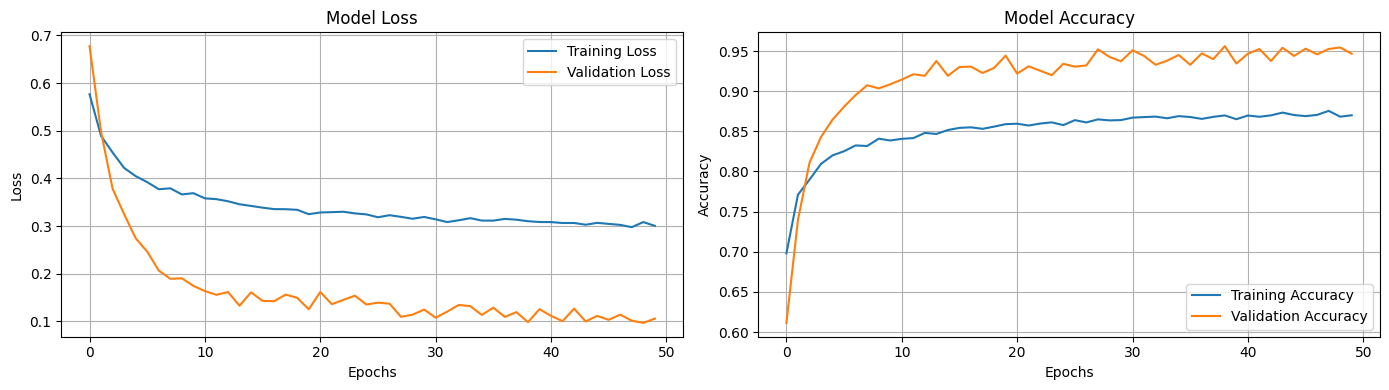

In [51]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [52]:
# Get probability predictions
y_pred_prob = model.predict(X_test).flatten()
print(f"Predictions shape: {y_pred_prob.shape}")
print(f"Test labels shape: {y_test.shape}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predictions shape: (2000,)
Test labels shape: (2000,)


In [53]:
# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


ROC-AUC Score: 0.8445


In [54]:
y_pred = (model.predict(X_test) > 0.4).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1460  133]
 [ 169  238]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1593
           1       0.64      0.58      0.61       407

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.84      0.85      0.85      2000



In [59]:
from sklearn.model_selection import train_test_split
# Split training data to create a validation set for threshold tuning
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Validation set size: {len(X_val)}")

Validation set size: 2548


In [60]:
# Train a quick model on the subset
temp_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

temp_model.compile(optimizer='adam', loss='binary_crossentropy')
temp_model.fit(X_train_sub, y_train_sub, epochs=20, batch_size=32, verbose=0)


In [61]:
# Get validation predictions
val_pred_prob = temp_model.predict(X_val).flatten()
print(f"Validation predictions shape: {val_pred_prob.shape}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Validation predictions shape: (2548,)


In [62]:
# Find optimal threshold
thresholds = np.arange(0.2, 0.8, 0.02)
f1_scores = []

for threshold in thresholds:
    y_pred_val = (val_pred_prob > threshold).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_val))

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold based on F1-score: {optimal_threshold:.2f}")

Optimal threshold based on F1-score: 0.42


In [63]:
print("\n" + "=" * 60)
print("FINAL PREDICTIONS")
print("=" * 60)

# Make predictions with optimal threshold
y_pred = (y_pred_prob > optimal_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


FINAL PREDICTIONS

Confusion Matrix:
[[1470  123]
 [ 175  232]]



Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.89      0.92      0.91      1593
     Churned       0.65      0.57      0.61       407

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.84      0.85      0.85      2000


PLOTTING CURVES


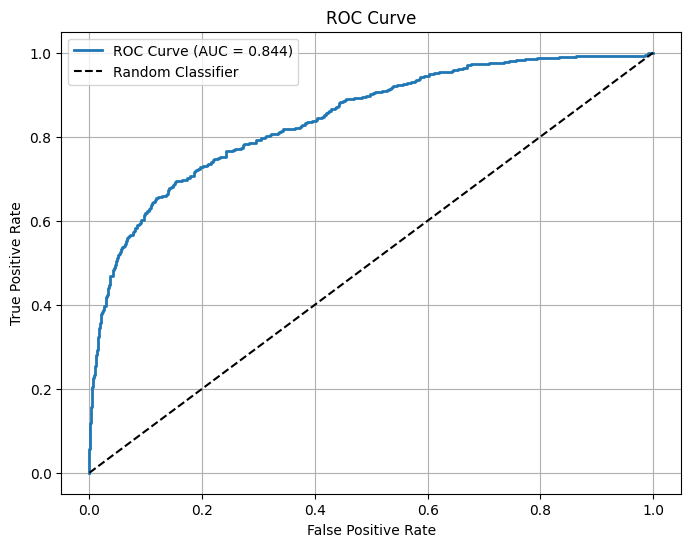

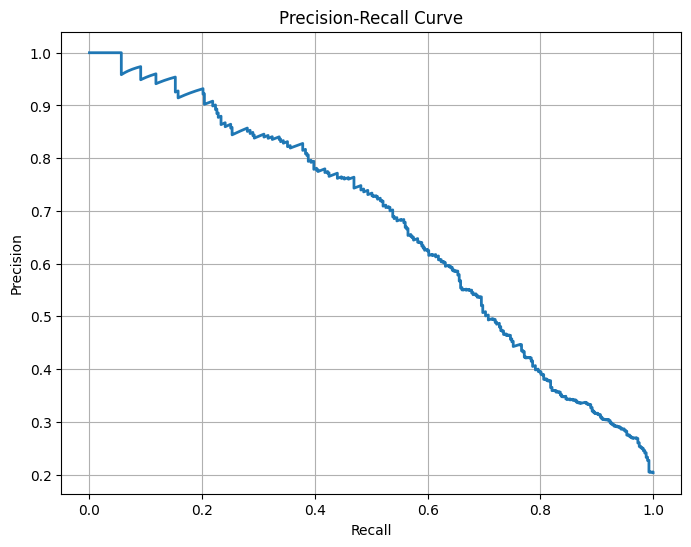

In [65]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['Not Churned', 'Churned']))

print("\n" + "=" * 60)
print("PLOTTING CURVES")
print("=" * 60)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [66]:
print("\n" + "=" * 60)
print("FINAL METRICS")
print("=" * 60)

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision_val * recall_val) / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")



FINAL METRICS
Optimal Threshold: 0.42
Accuracy: 0.8510
Precision: 0.6535
Recall: 0.5700
F1-Score: 0.6089
ROC-AUC: 0.8445


In [67]:
print("\n" + "=" * 60)
print("SAVING MODEL")
print("=" * 60)

# Save the model and threshold
model.save("../models/best_ann_model.keras")
joblib.dump(optimal_threshold, "../models/optimal_threshold.pkl")

print("Model saved to ../models/best_ann_model.keras")
print("Threshold saved to ../models/optimal_threshold.pkl")
print("\n" + "=" * 60)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 60)


SAVING MODEL
Model saved to ../models/best_ann_model.keras
Threshold saved to ../models/optimal_threshold.pkl

PROCESS COMPLETED SUCCESSFULLY
